# Markov chain ensembles using ReCom

Reference: PA_recom.ipynb from Prof. Veomett's AI for redistricting

## Initialization

In [1]:
import random
random.seed(12345678)

In [2]:
import matplotlib.pyplot as plt
from gerrychain import (GeographicPartition, Partition, Graph, MarkovChain,
                        proposals, updaters, constraints, accept, Election)
from gerrychain.proposals import recom
from gerrychain.tree import bipartition_tree
from functools import partial
import pandas as pd
import geopandas as gpd
import csv
import os
import datetime  #For keeping track of runtime
import tqdm # for progress bar

In [3]:
outdir="../data/AZ_recom_2020_CD/"

Here are some parameters that we can change later if we'd like. <br>
```save_district_plot_mod``` determines which plots (maps) we'll save.

In [4]:
total_steps_in_run=500
save_district_graph_mod=1
save_district_plot_mod=100

In [5]:
os.makedirs(outdir, exist_ok=True)
graph = Graph.from_file("../data/AZ_shapefile/AZ.shp")

In [6]:
elections = [
    Election("G20PRE", {"Democratic": "G20PRED", "Republican": "G20PRER"}),
    Election("G20USS", {"Democratic": "G20USSD", "Republican": "G20USSR"}),
]


In [7]:
my_updaters = {"population": updaters.Tally("TOTPOP", alias="population")}

In [8]:
election_updaters = {election.name: election for election in elections}
my_updaters.update(election_updaters)

In [9]:
initial_partition = GeographicPartition(graph, 
                                        assignment= "SEND",
                                        updaters=my_updaters)

## Setting up the Markov Chain

In [10]:
ideal_population = sum(initial_partition["population"].values()) / len(initial_partition)

In [11]:
proposal_recom = partial(recom,
                   pop_col="TOTPOP",
                   pop_target=ideal_population,
                   epsilon=0.02,
                   node_repeats=2,
                  )

In [12]:
method=partial(bipartition_tree,  # Use bipartition_tree method
                allow_pair_reselection=True  # Enable pair reselection
                )

In [18]:
proposal = partial(proposal_recom, method=method)

In [14]:
compactness_bound = constraints.UpperBound(
    lambda p: len(p["cut_edges"]),
    2*len(initial_partition["cut_edges"])
)

In [15]:
pop_constraint = constraints.within_percent_of_ideal_population(initial_partition, 0.10)

In [19]:
chain = MarkovChain(
    proposal=proposal,
    constraints=[
        pop_constraint,
        compactness_bound
    ],
    accept=accept.always_accept,
    initial_state=initial_partition,
    total_steps=total_steps_in_run
    )

## Running the chain

### The presidential

In [22]:
# Store the partitions in the chain
partitions_pre = [partition for partition in chain.with_progress_bar()]

100%|██████████████████████████████████████████████████████████████████████████| 500/500 [1:23:29<00:00, 10.02s/it]


#### Efficiency gap

In [23]:
from gerrychain.metrics.partisan import efficiency_gap

In [24]:
data_pre_eg = [efficiency_gap(partition['G20PRE']) for partition in partitions_pre]

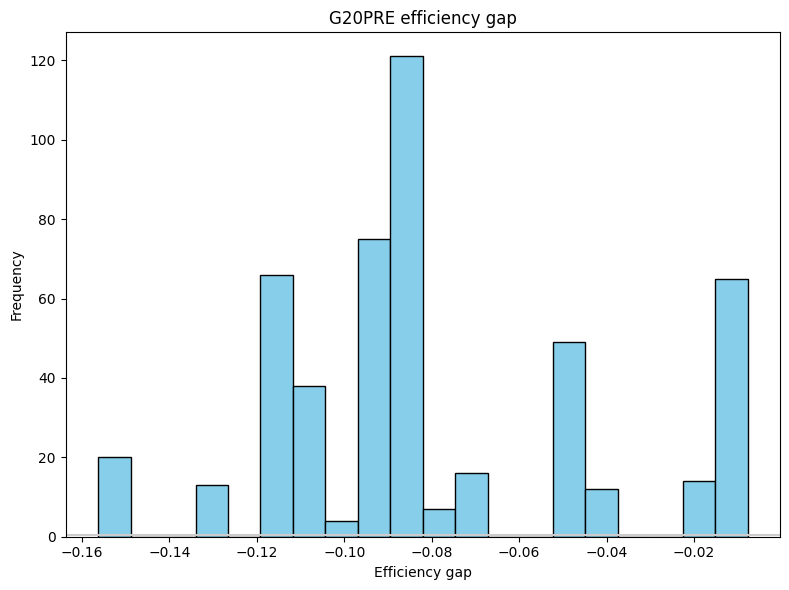

In [33]:
fig, ax = plt.subplots(figsize=(8, 6))

# Draw 50% line
ax.axhline(0.5, color="#cccccc")

# Draw histogram
ax.hist(data_pre_eg, bins=20, color='skyblue', edgecolor='black')

# Annotate
ax.set_title("G20PRE efficiency gap")
ax.set_ylabel("Frequency")
ax.set_xlabel("Efficiency gap")
plt.tight_layout()
plt.savefig(os.path.join(outdir, 'AZ_G20PRE_eg.png'))
plt.show()

#### Dem-won districts

In [31]:
data_pre_dw = [partition['G20PRE'].seats("Democratic") for partition in partitions_pre]
data_pre_dw[:10]

[14, 14, 14, 14, 14, 14, 14, 14, 14, 14]

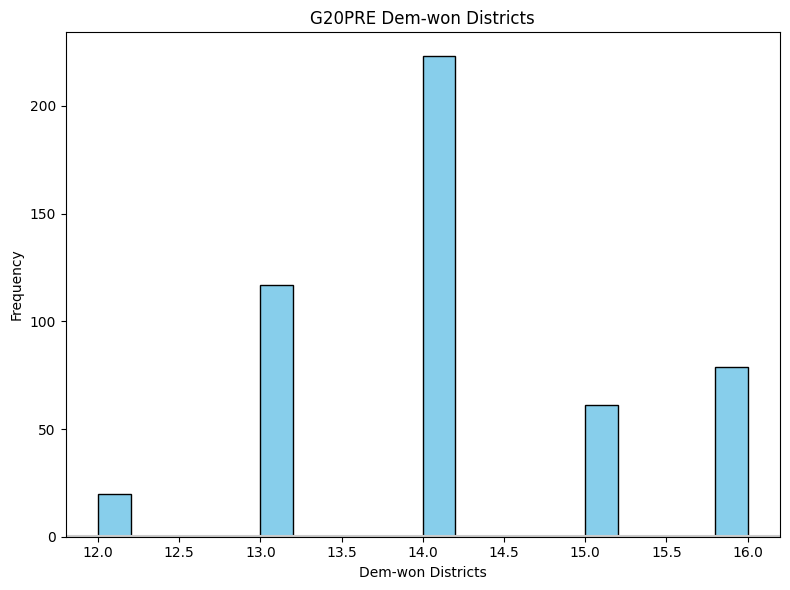

In [34]:
fig, ax = plt.subplots(figsize=(8, 6))

# Draw 50% line
ax.axhline(0.5, color="#cccccc")

# Draw histogram
ax.hist(data_pre_dw, bins=20, color='skyblue', edgecolor='black')

# Annotate
ax.set_title("G20PRE Dem-won Districts")
ax.set_ylabel("Frequency")
ax.set_xlabel("Dem-won Districts")
plt.tight_layout()
plt.savefig(os.path.join(outdir, 'AZ_G20PRE_dw.png'))
plt.show()

#### Cut edges

In [36]:
data_pre_ce = [len(partition['cut_edges']) for partition in partitions_pre]
data_pre_ce[:10]

[869, 876, 879, 882, 879, 875, 875, 881, 887, 880]

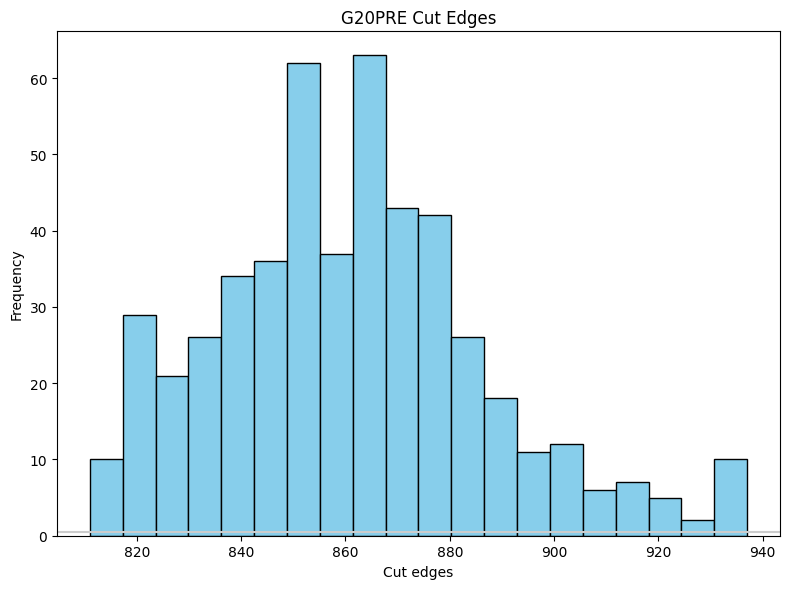

In [37]:
fig, ax = plt.subplots(figsize=(8, 6), tight_layout=True)

# Draw 50% line
ax.axhline(0.5, color="#cccccc")

# Draw histogram
ax.hist(data_pre_ce, bins=20, color='skyblue', edgecolor='black')

# Annotate
ax.set_title("G20PRE Cut Edges")
ax.set_ylabel("Frequency")
ax.set_xlabel("Cut edges")
plt.savefig(os.path.join(outdir, 'AZ_G20PRE_ce.png'))
plt.show()